# Full-frame Copernicus DEM object support

**Numerical question.** At the 2026-09-01 inventory snapshot, how many cells in the frozen 1,826-cell frame have a listed Copernicus DEM object for the reporting tile and for all nine tiles in its registered processing neighborhood? This notebook reads the frozen metadata tables only. It does not open a raster, test elevation validity, calculate terrain area, substitute a source, or amend the Issue 19 stop.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
root = Path('..')
cells = pd.read_csv(root/'data/global_dem_support/cell_support.csv')
groups = pd.read_csv(root/'data/global_dem_support/group_support.csv')
summary = json.loads((root/'data/global_dem_support/summary.json').read_text())
assert len(cells) == 3652 and cells.groupby('instance').size().eq(1826).all()
assert cells.groupby('instance').selected_annotation.sum().eq(96).all()
assert groups.groupby(['instance','dimension']).population_cells.sum().eq(1826).all()
stats = cells.groupby('instance').agg(population=('cell_key','size'), core=('core_object_present','sum'), full_halo=('full_halo_object_support','sum'))
stats['core_percent'] = 100*stats.core/stats.population
stats['full_halo_percent'] = 100*stats.full_halo/stats.population
stats


,population,core,full_halo,core_percent,full_halo_percent
instance,,,,,
glo30,1826,1822,1411,99.780942,77.272727
glo90,1826,1826,1422,100.000000,77.875137


GLO-90 lists the core object for every reporting cell; GLO-30 omits four core objects in dominant RGI region 12. Full-halo object support is lower for both products because the fixed neighborhood includes objects not listed by either inventory, including ocean-only tiles. Object listing is necessary but not sufficient for valid elevation support.

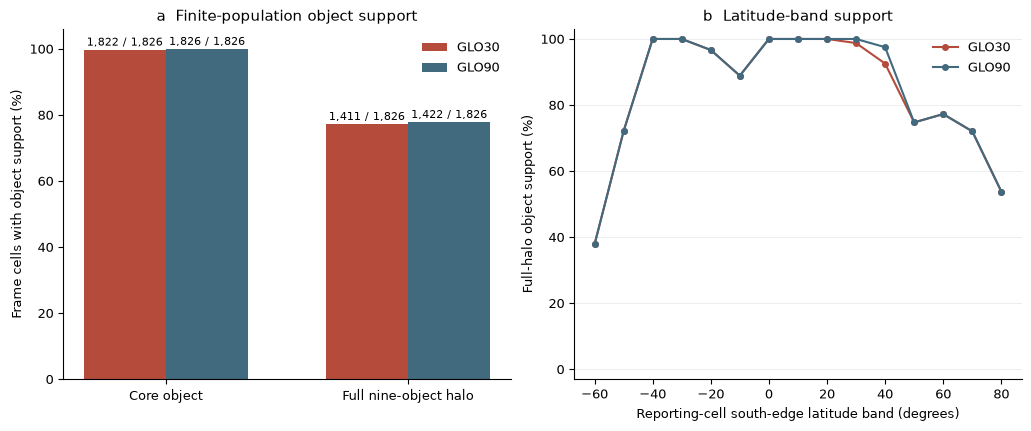

In [2]:
colors = {'glo30':'#b44b3b', 'glo90':'#426a7f'}
plt.rcParams.update({'font.size': 9, 'axes.spines.top': False, 'axes.spines.right': False})
fig, (ax, bx) = plt.subplots(1, 2, figsize=(10.2, 4.2), constrained_layout=True)
metrics = [('core','Core object'), ('full_halo','Full nine-object halo')]
x = np.arange(2); width = .34
for j, instance in enumerate(['glo30','glo90']):
    values = [100*stats.loc[instance,k]/stats.loc[instance,'population'] for k,_ in metrics]
    bars = ax.bar(x+(j-.5)*width, values, width, color=colors[instance], label=instance.upper())
    for bar, key in zip(bars, [k for k,_ in metrics]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2, f"{stats.loc[instance,key]:,} / 1,826", ha='center', fontsize=8)
ax.set(xticks=x, xticklabels=[x[1] for x in metrics], ylim=(0,106), ylabel='Frame cells with object support (%)', title='a  Finite-population object support'); ax.legend(frameon=False)
latitude = groups[groups.dimension.eq('latitude')].copy(); latitude['fraction'] = 100*latitude.full_halo_object_support_cells/latitude.population_cells
for instance in ['glo30','glo90']:
    q = latitude[latitude.instance.eq(instance)].sort_values('group')
    bx.plot(q.group, q.fraction, marker='o', ms=4, lw=1.5, color=colors[instance], label=instance.upper())
bx.set(xlabel='Reporting-cell south-edge latitude band (degrees)', ylabel='Full-halo object support (%)', ylim=(-3,103), title='b  Latitude-band support')
bx.grid(axis='y', color='#e4e7e9', linewidth=.5); bx.legend(frameon=False)
fig.savefig(root/'figures/global_dem_object_support.png', dpi=300, bbox_inches='tight')
fig.savefig(root/'figures/global_dem_object_support.pdf', bbox_inches='tight')
plt.show()
